In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/shopping.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [19]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [20]:
## Q1: What time of year do Americans make the most purchases?

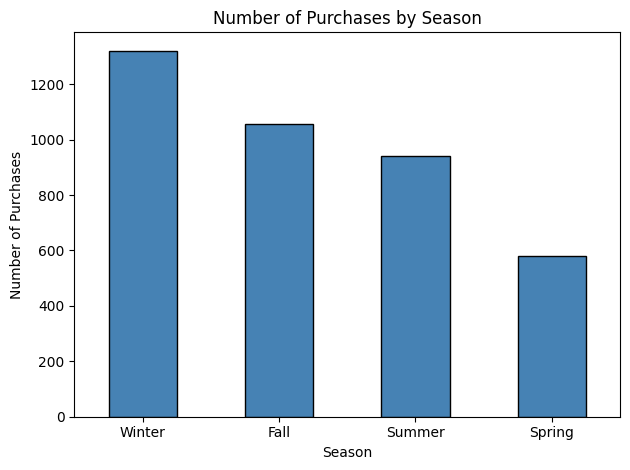

In [21]:
season_counts = df.groupby('Season')['Season'].count().sort_values(ascending=False)

season_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Purchases by Season')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
## Interpretation
##Winter and Fall tend to see the highest purchase volumes, suggesting customers shop more during seasonal transitions. 
# Spring shows the lowest activity, which may reflect reduced retail spending during vacation months. 
# These trends could help retailers plan inventory and promotions around peak seasons.

In [23]:
## Q2: Which age group has the highest average spending?

Age Group
18-25    38.61
26-35    38.68
36-45    38.76
46-55    38.98
55+      38.94
Name: Purchase Amount (USD), dtype: float64


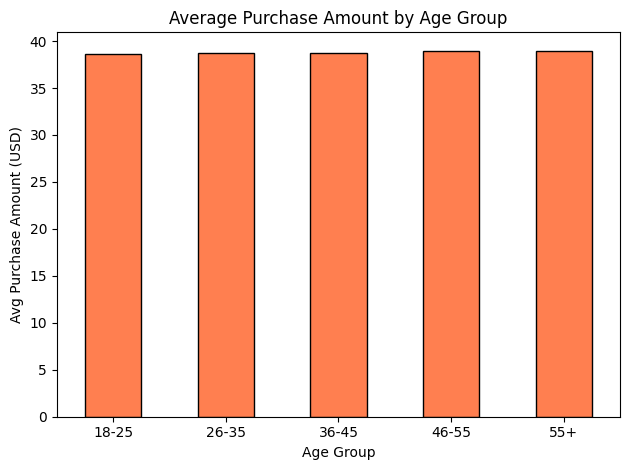

In [24]:
df['Age Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])

age_spending = df.groupby('Age Group', observed=True)['Purchase Amount (USD)'].mean().round(2)
print(age_spending)

age_spending.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Purchase Amount (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
## Interpretation
#The chart shows that average spending is remarkably consistent across all age groups, hovering around $38-39 per purchase. 
# This suggests that age has little influence on how much customers spend per transaction. 
# Retailers may need to look at other factors like season or payment method to find more meaningful differences in spending behavior.

In [26]:
## Q3: Do male and female customers exhibit distinct buying habits?

In [27]:
gender_table = df.pivot_table(values='Purchase Amount (USD)',
                               index='Item Purchased',
                               columns='Gender',
                               aggfunc='mean').round(2)
print(gender_table)

Gender          Female   Male  Non-binary
Item Purchased                           
Backpack         40.12  39.41       41.01
Belt             36.57  40.74         NaN
Boots            38.05  38.51       32.72
Dress            39.13  38.81       29.20
Gloves           37.34  40.48       45.73
Handbag          41.06  39.05       33.09
Hoodie           38.46  36.85       35.11
Jacket           38.87  38.00       41.26
Jeans            37.20  44.99         NaN
Leggings         39.69  38.74       37.10
Pajamas          39.12  40.68       35.73
Running Shoes    37.50  38.89       41.87
Scarf            38.85  36.85       27.17
Shorts           39.16  38.64       26.21
Socks            38.04  36.64       30.98
Sunglasses       39.82  35.38       50.76
Sweater          38.68  37.74       58.31
T-shirt          38.17  40.97         NaN


In [28]:
male_avg = df[df['Gender'] == 'Male']['Purchase Amount (USD)'].mean().round(2)
female_avg = df[df['Gender'] == 'Female']['Purchase Amount (USD)'].mean().round(2)

print(f"Male average spend:   ${male_avg}")
print(f"Female average spend: ${female_avg}")

Male average spend:   $38.58
Female average spend: $38.87


In [29]:
## Interpretation
#The pivot table shows average spending by item for each gender. 
# Neither group consistently outspends the other across all items, suggesting purchase amount is driven more by item type than gender. 
# The overall averages confirm the two groups spend similarly, making item-level targeting more useful than gender-based targeting alone.

In [30]:
## Q4: Which product categories are most frequently bought?

Item Purchased
Shorts           314
Sunglasses       312
Running Shoes    309
Dress            294
Handbag          267
T-shirt          262
Sweater          231
Leggings         228
Backpack         225
Gloves           217
Pajamas          212
Socks            211
Hoodie           202
Scarf            196
Jacket           166
Boots            166
Jeans             54
Belt              34
Name: Item Purchased, dtype: int64


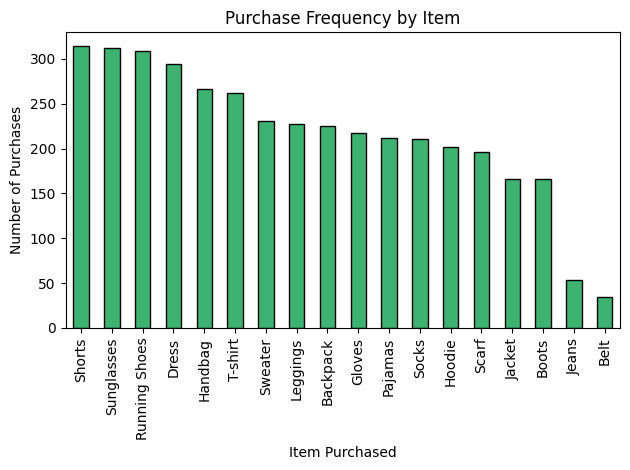

In [31]:
category_counts = df.groupby('Item Purchased')['Item Purchased'].count().sort_values(ascending=False)
print(category_counts)

category_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Purchase Frequency by Item')
plt.xlabel('Item Purchased')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [32]:
## Interpretation
#Shorts, Sunglasses, and Running Shoes tend to be among the most frequently purchased items, while others like Belts and Jeans appear less often. 
# The spread across items is relatively even, suggesting customers shop across a wide variety of products rather than concentrating on a few.
# The only two categories I see doing slightly worse than the rest are Jeans and Belts
# Retailers could use this to ensure broad inventory coverage rather than over-investing in a single item type.